<a href="https://colab.research.google.com/github/NikoriakViktot/PY-Course-Victor-Nikoriak-22-09-2026/blob/main/module_1/lessons/lesson_06_dicts_loops_comprehensions/restoran_tips_draft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

## 📐 Архітектура: які структури даних нам потрібні

Перш ніж писати код — треба зрозуміти **як організувати дані**. Це найважливіший крок.

```
Система ресторану
│
├── List  ──── список усіх чеків за вечір
│                [чек1, чек2, чек3, ...]
│
├── Tuple ──── один чек: (офіціант, сума_рахунку, чайові)
│                ('Олексій', 450, 90)
│
├── Dict  ──── чайові зібрані по кожному офіціанту
│                { 'Олексій': 380, 'Марія': 450, ... }
│
└── Set   ──── унікальні імена — без дублікатів
                 { 'Олексій', 'Марія', 'Іван', 'Катерина' }
```

**Чому кортеж для чека?**
Тому що чек — це **факт**, що вже відбувся. Його не потрібно змінювати.
Кортеж захищає дані від випадкових змін — це і є його призначення.

---

## Крок 1: Створюємо дані

Окей, починаємо. Перше що нам потрібно — це самі чеки.

Кожен чек — це **кортеж** з трьох значень:
- ім'я офіціанта  
- сума рахунку (гривні)  
- чайові (гривні)

Чому кортеж, а не список? Бо чек вже виписаний — ніхто не має його міняти.
Кортеж — це «заморожений» запис.

Я запишу кілька реальних чеків вечірньої зміни:


In [2]:
# Кожен чек — кортеж (офіціант, сума_рахунку, чайові)
# Кортеж тому що чек — незмінний факт

orders = [
    ('Олексій',  450,  90),
    ('Марія',    820, 150),
    ('Олексій',  310,  60),
    ('Іван',     290,  40),
    ('Марія',    640, 120),
    ('Олексій',  510, 100),
    ('Іван',     380,  70),
    ('Марія',    920, 180),
    ('Катерина', 730, 140),
    ('Іван',     240,  30),
    ('Катерина', 550, 110),
    ('Олексій',  670, 130),
]

print(f"Всього чеків за вечір: {len(orders)}")
print()
print("Перші 3 чеки:")
for order in orders[:3]:
    print(f"  {order}")
print()

# Подивимось на один чек — як отримати його поля?
first_order = orders[0]
print(f"Перший чек: {first_order}")
print(f"  Офіціант: {first_order[0]}")
print(f"  Рахунок : {first_order[1]} грн")
print(f"  Чайові  : {first_order[2]} грн")

Всього чеків за вечір: 12

Перші 3 чеки:
  ('Олексій', 450, 90)
  ('Марія', 820, 150)
  ('Олексій', 310, 60)

Перший чек: ('Олексій', 450, 90)
  Офіціант: Олексій
  Рахунок : 450 грн
  Чайові  : 90 грн


### Альтернатива: NamedTuple — коли індекси незрозумілі

Зверніть увагу на звичайний кортеж:

```python
order[0]   # що це? ім'я? номер столу?
order[2]   # а це? чайові? знижка?
```

Числові індекси — погана підказка. Якщо повернутися до цього коду через тиждень,
доведеться згадувати що де лежить.

`NamedTuple` вирішує це: поля отримують **імена**, код стає самодокументованим.

```python
order.waiter   # одразу зрозуміло
order.tip      # не треба рахувати індекси
```

При цьому `NamedTuple` — це той самий кортеж: незмінний, займає стільки ж пам'яті,
підтримує розпакування та індексацію.


In [3]:
from typing import NamedTuple

# Визначаємо структуру чека — один раз, для всієї програми
class Order(NamedTuple):
    waiter: str
    bill:   float
    tip:    float

# Ті самі дані — тепер у вигляді NamedTuple
orders_named = [
    Order('Олексій',  450,  90),
    Order('Марія',    820, 150),
    Order('Олексій',  310,  60),
    Order('Іван',     290,  40),
    Order('Марія',    640, 120),
    Order('Олексій',  510, 100),
    Order('Іван',     380,  70),
    Order('Марія',    920, 180),
    Order('Катерина', 730, 140),
    Order('Іван',     240,  30),
    Order('Катерина', 550, 110),
    Order('Олексій',  670, 130),
]

# Порівнюємо доступ до полів
plain  = orders[0]
named  = orders_named[0]

print("=== Доступ до полів ===")
print()
print("Звичайний tuple:")
print(f"  order[0]  = {plain[0]!r:<12}  ← що це?")
print(f"  order[2]  = {plain[2]!r:<12}  ← а це?")
print()
print("NamedTuple:")
print(f"  order.waiter = {named.waiter!r:<12}  ← очевидно")
print(f"  order.tip    = {named.tip!r:<12}  ← очевидно")
print()

# NamedTuple підтримує все що й звичайний кортеж
print("=== NamedTuple — це все ще кортеж ===")
print(f"  isinstance(named, tuple)  = {isinstance(named, tuple)}")
print(f"  named[0]                  = {named[0]!r}   ← індекс працює")
waiter, bill, tip = named              # розпакування теж працює
print(f"  w, b, t = named  →  {waiter}, {bill}, {tip}")
print()

# Захист від помилок
try:
    named.waiter = 'Хтось'
except AttributeError as e:
    print(f"  named.waiter = ...  →  AttributeError: {e}")
print()

# repr — самодокументований вивід
print("=== repr ===")
print(f"  tuple  : {plain}")
print(f"  named  : {named}")
print("  NamedTuple показує імена полів — tuple ні")

=== Доступ до полів ===

Звичайний tuple:
  order[0]  = 'Олексій'     ← що це?
  order[2]  = 90            ← а це?

NamedTuple:
  order.waiter = 'Олексій'     ← очевидно
  order.tip    = 90            ← очевидно

=== NamedTuple — це все ще кортеж ===
  isinstance(named, tuple)  = True
  named[0]                  = 'Олексій'   ← індекс працює
  w, b, t = named  →  Олексій, 450, 90

  named.waiter = ...  →  AttributeError: can't set attribute

=== repr ===
  tuple  : ('Олексій', 450, 90)
  named  : Order(waiter='Олексій', bill=450, tip=90)
  NamedTuple показує імена полів — tuple ні


In [4]:
# Алгоритм з NamedTuple — читабельніший код
from collections import defaultdict, Counter

tips_named  = defaultdict(float)
count_named = Counter()

for order in orders_named:
    tips_named[order.waiter]  += order.tip    # order.tip замість order[2]
    count_named[order.waiter] += 1

leader_named = max(tips_named, key=tips_named.get)

print("=== Звіт (через NamedTuple) ===")
for rank, (waiter, total) in enumerate(
    sorted(tips_named.items(), key=lambda x: x[1], reverse=True), 1
):
    avg = total / count_named[waiter]
    print(f"  {rank}. {waiter:<12} {total:>4.0f} грн  ~{avg:.0f}/чек")
print(f"\n  Лідер: {leader_named}")
print()

# Підсумкове порівняння підходів
print("=" * 48)
print("  ЯКИЙ ВАРІАНТ ОБРАТИ?")
print("=" * 48)
print()
print("  Звичайний tuple:")
print("    (+) менше коду при визначенні")
print("    (-) order[0], order[2] — незрозуміло")
print("    (-) легко переплутати індекси")
print()
print("  NamedTuple:")
print("    (+) order.waiter, order.tip — самодокументовано")
print("    (+) захист від опечаток (AttributeError)")
print("    (+) repr показує імена полів")
print("    (+) та сама швидкість і пам'ять що й tuple")
print("    (-) потрібно визначити клас заздалегідь")
print()
print("  Правило: якщо поля мають зрозумілий сенс — використовуй NamedTuple.")

=== Звіт (через NamedTuple) ===
  1. Марія         450 грн  ~150/чек
  2. Олексій       380 грн  ~95/чек
  3. Катерина      250 грн  ~125/чек
  4. Іван          140 грн  ~47/чек

  Лідер: Марія

  ЯКИЙ ВАРІАНТ ОБРАТИ?

  Звичайний tuple:
    (+) менше коду при визначенні
    (-) order[0], order[2] — незрозуміло
    (-) легко переплутати індекси

  NamedTuple:
    (+) order.waiter, order.tip — самодокументовано
    (+) захист від опечаток (AttributeError)
    (+) repr показує імена полів
    (+) та сама швидкість і пам'ять що й tuple
    (-) потрібно визначити клас заздалегідь

  Правило: якщо поля мають зрозумілий сенс — використовуй NamedTuple.


---

## 🌍 Реальний датасет: де насправді живуть дані

Ми щойно написали дані вручну. Але в реальному житті чеки приходять з **POS-системи**, бази даних або CSV-файлу.

Як виглядають справжні ресторанні дані? Скористаємось вбудованим датасетом `seaborn` — він містить **244 реальних чеки** з американського ресторану.

| Колонка | Значення |
|---------|---------|
| `total_bill` | сума рахунку (USD) |
| `tip` | чайові (USD) |
| `sex` | стать відвідувача |
| `smoker` | палить? |
| `day` | день тижня |
| `time` | Lunch / Dinner |
| `size` | кількість людей за столом |

Це наш місток між навчальним прикладом і реальним аналізом даних.


### Перетворення DataFrame → наша структура даних

DataFrame — це таблиця pandas. Наш алгоритм очікує **список кортежів**.
Перетворимо реальні дані у точно таку саму структуру як `orders`.

Офіціантів у датасеті немає — симулюємо їх через `day + time`
(в реальному ресторані офіціант прив'язаний до зміни).

```
DataFrame рядок:
  total_bill=16.99   tip=1.01   day=Sun   time=Dinner
                          ↓
Кортеж (наша структура):
  ('Sun_Dinner', 16.99, 1.01)
```

**Ключовий момент:** алгоритм не знає і не піклується звідки прийшли дані.

### Той самий алгоритм — нові дані

> **Це найважливіший момент уроку.**

Алгоритм не знає звідки прийшли дані. Йому байдуже: ручний список, CSV, база даних чи API. Якщо структура однакова — код працює без змін.

```
CSV файл    ────┐
База даних  ────┤──► перетворення ──► list[tuple] ──► наш алгоритм
API         ────┤
DataFrame   ────┘
```

### Візуалізація: від алгоритмів до аналітики

Тепер зробимо крок далі — побудуємо графіки прямо з реальних даних.
Це природне продовження нашого pipeline:

```
DataFrame → list[tuple] → алгоритм → dict → графік
```

### Що ми щойно пройшли

```
штучні дані (12 чеків)
        ↓
  алгоритм while
        ↓
реальний датасет (244 чеки, seaborn)
        ↓
  той самий алгоритм — без змін
        ↓
  візуалізація (matplotlib + seaborn)
```

**Головний висновок:**
Алгоритм — це **незалежна одиниця логіки**.
Джерело даних (ручний список, CSV, DataFrame, API) — лише вхід.
Як тільки дані мають однакову структуру `(waiter, bill, tip)` —
весь ваш код працює без жодних змін.


---

## Крок 2: Думаємо перед тим як кодити

Добре, дані є. Тепер давайте зупинимось і подумаємо **що саме ми робимо**,
перш ніж братися за клавіатуру.

Нам потрібно пройти по списку чеків і **накопичити** чайові по кожному офіціанту.
Кінцевий результат — словник вигляду:

```
{
  'Олексій':  380,
  'Марія':    450,
  'Іван':     140,
  'Катерина': 250,
}
```

**Три питання перед будь-яким алгоритмом:**

1. Як я отримую кожен елемент? → беру `orders[i]` за індексом  
2. Що я роблю з кожним елементом? → дивлюсь хто офіціант, беру чайові  
3. Де я зберігаю результат? → у словнику `tips_by_waiter`  

```
СТАРТ
│
├── i = 0                            ← лічильник
│
└── ПОКИ i < кількість чеків:
    │
    ├── взяти чек orders[i]
    ├── витягти офіціанта і чайові
    │
    ├── офіціант ВПЕРШЕ? → створити запис: tips[waiter] = 0
    ├── офіціант ВЖЕ Є?  → просто додати: tips[waiter] += tip
    │
    └── i += 1   ← ОБОВ'ЯЗКОВО, інакше нескінченний цикл!
```


In [10]:
# Крок 2: Накопичуємо чайові по кожному офіціанту
# Спочатку пишемо «довгим» способом — щоб побачити кожен крок

tips_by_waiter = {}   # порожній словник — сюди накопичуємо

i = 0                 # лічильник — починаємо з першого чека

while i < len(orders):

    # Беремо поточний чек
    order = orders[i]

    # Витягуємо потрібні поля (індекси кортежу)
    waiter = order[0]   # ім'я офіціанта
    tip    = order[2]   # чайові (нас цікавлять, а не сума рахунку)

    # Ключовий момент: офіціант вперше зустрічається чи вже є?
    if waiter not in tips_by_waiter:
        # ВПЕРШЕ: створюємо запис з нулем
        tips_by_waiter[waiter] = 0

    # Додаємо чайові (і для першого разу, і для наступних — однаково)
    tips_by_waiter[waiter] += tip

    i += 1              # ОБОВ'ЯЗКОВО: пересуваємось на наступний чек

print("Чайові по офіціантах:")
for waiter, total in tips_by_waiter.items():
    print(f"  {waiter:<12}: {total:>4} грн")

Чайові по офіціантах:
  Олексій     :  380 грн
  Марія       :  450 грн
  Іван        :  140 грн
  Катерина    :  250 грн


**Пояснення ключового рядка `if waiter not in tips_by_waiter`:**

Уявіть словник як таблицю, яка поступово заповнюється:

```
Чек 1: ('Олексій', 450, 90)
  → 'Олексій' у словнику? НІ  → створюємо: {'Олексій': 0}
  → додаємо 90:               → {'Олексій': 90}

Чек 2: ('Марія', 820, 150)
  → 'Марія' у словнику?    НІ  → {'Олексій': 90, 'Марія': 0}
  → додаємо 150:               → {'Олексій': 90, 'Марія': 150}

Чек 3: ('Олексій', 310, 60)
  → 'Олексій' у словнику?  ТАК → нічого не створюємо
  → додаємо 60:               → {'Олексій': 150, 'Марія': 150}
...
```

Це класична техніка **«накопичувальний словник»** —
один з найважливіших патернів у програмуванні.


In [11]:
# Подивимось покроково як заповнюється словник (перші 5 чеків)
trace = {}
print("Покроковий трейс (перші 5 чеків):")
print(f"  Старт: {trace}")

for order in orders[:5]:
    waiter = order[0]
    tip    = order[2]

    is_new = waiter not in trace
    if is_new:
        trace[waiter] = 0
    trace[waiter] += tip

    status = "НОВИЙ" if is_new else "+=   "
    print(f"  [{status}] {order} → {trace}")

Покроковий трейс (перші 5 чеків):
  Старт: {}
  [НОВИЙ] ('Олексій', 450, 90) → {'Олексій': 90}
  [НОВИЙ] ('Марія', 820, 150) → {'Олексій': 90, 'Марія': 150}
  [+=   ] ('Олексій', 310, 60) → {'Олексій': 150, 'Марія': 150}
  [НОВИЙ] ('Іван', 290, 40) → {'Олексій': 150, 'Марія': 150, 'Іван': 40}
  [+=   ] ('Марія', 640, 120) → {'Олексій': 150, 'Марія': 270, 'Іван': 40}


---

## Крок 3: Знаходимо лідера

Тепер у нас є словник із сумами. Треба знайти **хто заробив найбільше**.

Класичний алгоритм пошуку максимуму — **«поточний чемпіон»**:

```
Припускаємо: перший офіціант — чемпіон.

ПОКИ є ще офіціанти:
  якщо поточний кращий за чемпіона → він стає новим чемпіоном

Наприкінці чемпіон = лідер.
```

Ми ніколи не знаємо заздалегідь хто переможе — тому перевіряємо всіх.


In [12]:
# Крок 3: Знаходимо лідера — алгоритм «поточний чемпіон»

# Перетворюємо словник на список пар [(офіціант, чайові), ...]
# щоб можна було ітерувати з while і мати доступ за індексом
waiters_list = list(tips_by_waiter.items())
print("Список пар (офіціант, чайові):")
for pair in waiters_list:
    print(f"  {pair}")
print()

# Ініціалізація: перший у списку — наш стартовий «чемпіон»
leader   = waiters_list[0][0]   # ім'я
max_tips = waiters_list[0][1]   # його чайові — поки «рекорд»

print(f"Стартовий чемпіон: {leader} ({max_tips} грн)")
print()

i = 1   # починаємо з ДРУГОГО (першого вже взяли як чемпіона)

while i < len(waiters_list):
    waiter, tips = waiters_list[i]   # розпакування пари

    if tips > max_tips:              # новий рекорд?
        leader   = waiter
        max_tips = tips
        print(f"  Новий лідер: {leader} ({max_tips} грн)!")
    else:
        print(f"  {waiter} ({tips} грн) — не перевищує {max_tips} грн")

    i += 1

print()
print(f"🏆 Лідер вечора: {leader} з {max_tips} грн чайових")

Список пар (офіціант, чайові):
  ('Олексій', 380)
  ('Марія', 450)
  ('Іван', 140)
  ('Катерина', 250)

Стартовий чемпіон: Олексій (380 грн)

  Новий лідер: Марія (450 грн)!
  Іван (140 грн) — не перевищує 450 грн
  Катерина (250 грн) — не перевищує 450 грн

🏆 Лідер вечора: Марія з 450 грн чайових


---

## Крок 4: Унікальні офіціанти

Власник також хоче знати: **скільки різних офіціантів** працювало цього вечора?

Тут ідеально підходить `set`. Його суперсила —
**автоматично ігнорує дублікати**. Я можу просто додавати ім'я кожного разу,
і множина сама забезпечить унікальність.

Підхід:
```
Створити порожню множину

ПОКИ є чеки:
  взяти ім'я офіціанта
  додати у множину  ← якщо вже є — нічого не відбудеться

Наприкінці в множині — тільки унікальні імена
```

In [13]:
# Крок 4: Збираємо унікальних офіціантів за допомогою set

unique_waiters = set()   # порожня множина

i = 0
while i < len(orders):
    waiter = orders[i][0]         # ім'я з кортежу
    unique_waiters.add(waiter)    # set сам прибере дублікати
    i += 1

print(f"Унікальні офіціанти: {unique_waiters}")
print(f"Кількість          : {len(unique_waiters)}")
print()

# Покажемо що відбувається покроково
print("Покроково (всі чеки):")
growing_set = set()
for order in orders:
    before = len(growing_set)
    growing_set.add(order[0])
    after  = len(growing_set)
    status = "додано" if after > before else "вже є "
    print(f"  [{status}] '{order[0]:<10}' → {growing_set}")

Унікальні офіціанти: {'Іван', 'Олексій', 'Катерина', 'Марія'}
Кількість          : 4

Покроково (всі чеки):
  [додано] 'Олексій   ' → {'Олексій'}
  [додано] 'Марія     ' → {'Олексій', 'Марія'}
  [вже є ] 'Олексій   ' → {'Олексій', 'Марія'}
  [додано] 'Іван      ' → {'Іван', 'Олексій', 'Марія'}
  [вже є ] 'Марія     ' → {'Іван', 'Олексій', 'Марія'}
  [вже є ] 'Олексій   ' → {'Іван', 'Олексій', 'Марія'}
  [вже є ] 'Іван      ' → {'Іван', 'Олексій', 'Марія'}
  [вже є ] 'Марія     ' → {'Іван', 'Олексій', 'Марія'}
  [додано] 'Катерина  ' → {'Іван', 'Олексій', 'Катерина', 'Марія'}
  [вже є ] 'Іван      ' → {'Іван', 'Олексій', 'Катерина', 'Марія'}
  [вже є ] 'Катерина  ' → {'Іван', 'Олексій', 'Катерина', 'Марія'}
  [вже є ] 'Олексій   ' → {'Іван', 'Олексій', 'Катерина', 'Марія'}


---

## Крок 5: Рахуємо загальну статистику

Залишилось порахувати загальний виторг і загальні чайові за вечір.
Це простий один прохід по списку — накопичуємо суму.



In [20]:
# Альтернатива 4: пошук лідера через max()

# Наш while-варіант (8 рядків):
# waiters_list = list(tips_by_waiter.items())
# leader = waiters_list[0][0]
# max_tips = waiters_list[0][1]
# i = 1
# while i < len(waiters_list):
#     waiter, tips = waiters_list[i]
#     if tips > max_tips:
#         leader = waiter; max_tips = tips
#     i += 1

# Пітонічний варіант (1 рядок):
leader_v2 = max(tips_by_waiter, key=tips_by_waiter.get)
# max() проходить по ключах (офіціантах)
# key=tips_by_waiter.get → для порівняння використовує значення (чайові)

print(f"Лідер (while):  {leader}")
print(f"Лідер (max()):  {leader_v2}")
print(f"Однакові: {leader == leader_v2}")
print()

# Якщо потрібен і лідер, і сума — через max() з .items()
leader_v3, max_v3 = max(tips_by_waiter.items(), key=lambda pair: pair[1])
print(f"Через lambda: {leader_v3} → {max_v3} грн")
print()

# Як читається: max(items, ключ=друге значення пари)
# pair = ('Марія', 450) → pair[1] = 450 — ось що ми порівнюємо

Лідер (while):  Марія
Лідер (max()):  Марія
Однакові: True

Через lambda: Марія → 450 грн



In [14]:
# Крок 5: Загальний виторг і чайові за вечір

total_bills = 0
total_tips  = 0

i = 0
while i < len(orders):
    total_bills += orders[i][1]   # сума рахунку — індекс 1
    total_tips  += orders[i][2]   # чайові — індекс 2
    i += 1

tip_rate = total_tips / total_bills * 100

print(f"Загальний виторг : {total_bills} грн")
print(f"Загальні чайові  : {total_tips} грн")
print(f"Відсоток чайових : {tip_rate:.1f}%")

Загальний виторг : 6510 грн
Загальні чайові  : 1220 грн
Відсоток чайових : 18.7%


---

## Крок 6: Збираємо повний звіт

Все готово — збираємо всі результати разом і виводимо гарний звіт для власника.

In [15]:
# Крок 6: Повний звіт

# Сортуємо офіціантів за чайовими (від більшого до меншого)
sorted_waiters = sorted(tips_by_waiter.items(), key=lambda x: x[1], reverse=True)

print("=" * 44)
print("       ЗВІТ ЗА ВЕЧІРНЮ ЗМІНУ")
print("=" * 44)
print(f"  Чеків оброблено : {len(orders)}")
print(f"  Офіціантів      : {len(unique_waiters)}")
print(f"  Загальний виторг: {total_bills:>7} грн")
print(f"  Загальні чайові : {total_tips:>7} грн  ({tip_rate:.1f}%)")
print("-" * 44)
print("  Рейтинг офіціантів:")

for rank, (waiter, tips) in enumerate(sorted_waiters, start=1):
    bar = '█' * (tips // 25)    # візуальний бар пропорційно
    pct = tips / total_tips * 100
    print(f"  {rank}. {waiter:<12} {tips:>4} грн  {pct:>4.0f}%  {bar}")

print("-" * 44)
print(f"  🏆 Лідер вечора: {leader} ({max_tips} грн)")
print("=" * 44)

       ЗВІТ ЗА ВЕЧІРНЮ ЗМІНУ
  Чеків оброблено : 12
  Офіціантів      : 4
  Загальний виторг:    6510 грн
  Загальні чайові :    1220 грн  (18.7%)
--------------------------------------------
  Рейтинг офіціантів:
  1. Марія         450 грн    37%  ██████████████████
  2. Олексій       380 грн    31%  ███████████████
  3. Катерина      250 грн    20%  ██████████
  4. Іван          140 грн    11%  █████
--------------------------------------------
  🏆 Лідер вечора: Марія (450 грн)


---

## 🐍 Пітонічна версія: те саме, але коротше

Ми написали все «довгим» способом з `while` і явними індексами —
щоб зрозуміти **як це працює зсередини**.

Але досвідчені Python-розробники написали б те саме набагато коротше.
Подивимось як — і зрозуміємо чому кожен варіант кращий за попередній.

### Альтернатива 1: `for` + розпакування кортежу

Замість `while i < len(orders): ... i += 1` можна просто `for order in orders`.
А кортеж можна **розпакувати прямо в заголовку циклу** — це дуже зручно:


In [16]:
# Альтернатива 1: for + розпакування — замість while з індексами

tips_v2 = {}

for waiter, bill, tip in orders:    # розпакуємо кортеж прямо тут!
    if waiter not in tips_v2:
        tips_v2[waiter] = 0
    tips_v2[waiter] += tip

print("tips_v2:", tips_v2)
print(f"Той самий результат що і while: {tips_v2 == tips_by_waiter}")
print()
print("Що змінилось:")
print("  БУЛО: while i < len(orders): order = orders[i]; waiter = order[0]; tip = order[2]; i += 1")
print("  СТАЛО: for waiter, bill, tip in orders:")
print("  Зникли: лічильник i, orders[i], order[0], order[2], i += 1")

tips_v2: {'Олексій': 380, 'Марія': 450, 'Іван': 140, 'Катерина': 250}
Той самий результат що і while: True

Що змінилось:
  БУЛО: while i < len(orders): order = orders[i]; waiter = order[0]; tip = order[2]; i += 1
  СТАЛО: for waiter, bill, tip in orders:
  Зникли: лічильник i, orders[i], order[0], order[2], i += 1


### Альтернатива 2: `dict.get()` — позбуваємось `if`

`dict.get(key, default)` — якщо ключа немає, повертає `default` замість помилки.
Це дозволяє замінити блок `if waiter not in tips` одним рядком:

In [17]:
# Альтернатива 2: dict.get() — прибираємо if

tips_v3 = {}

for waiter, bill, tip in orders:
    tips_v3[waiter] = tips_v3.get(waiter, 0) + tip
    # .get(waiter, 0):
    #   якщо ключа немає → повертає 0  (перший раз: 0 + tip)
    #   якщо є           → повертає поточне значення

print("tips_v3:", tips_v3)
print(f"Той самий результат: {tips_v3 == tips_by_waiter}")
print()

# Демонстрація .get()
d = {'Alice': 100}
print("Як працює .get():")
print(f"  d = {d}")
print(f"  d.get('Alice', 0) = {d.get('Alice', 0)}   ← ключ є, повертає значення")
print(f"  d.get('Bob',   0) = {d.get('Bob',   0)}     ← ключа немає, повертає 0")
print(f"  d.get('Bob')      = {d.get('Bob')}      ← за замовчуванням None")

tips_v3: {'Олексій': 380, 'Марія': 450, 'Іван': 140, 'Катерина': 250}
Той самий результат: True

Як працює .get():
  d = {'Alice': 100}
  d.get('Alice', 0) = 100   ← ключ є, повертає значення
  d.get('Bob',   0) = 0     ← ключа немає, повертає 0
  d.get('Bob')      = None      ← за замовчуванням None


### Альтернатива 3: `defaultdict` — зовсім без умов

`defaultdict(int)` — спеціальний словник, який автоматично створює `0` для будь-якого
нового ключа. Тоді не потрібні ні `if`, ні `.get()`:


In [18]:
# Альтернатива 3: defaultdict — найчистіший варіант для накопичення
from collections import defaultdict

tips_v4 = defaultdict(int)   # int() = 0 для будь-якого нового ключа

for waiter, bill, tip in orders:
    tips_v4[waiter] += tip   # перший раз: 0 + tip; далі накопичуємо

print("tips_v4:", dict(tips_v4))
print(f"Той самий результат: {dict(tips_v4) == tips_by_waiter}")

tips_v4: {'Олексій': 380, 'Марія': 450, 'Іван': 140, 'Катерина': 250}
Той самий результат: True


In [19]:
# Порівняємо всі 4 підходи поруч
print("=" * 56)
print("  ПОРІВНЯННЯ ПІДХОДІВ")
print("=" * 56)
print()
print("① while + if (новачок — розуміємо механіку):")
print("  tips = {}")
print("  i = 0")
print("  while i < len(orders):")
print("      waiter = orders[i][0]")
print("      tip = orders[i][2]")
print("      if waiter not in tips:")
print("          tips[waiter] = 0")
print("      tips[waiter] += tip")
print("      i += 1")
print()
print("② for + if (краще — немає лічильника):")
print("  for waiter, bill, tip in orders:")
print("      if waiter not in tips:")
print("          tips[waiter] = 0")
print("      tips[waiter] += tip")
print()
print("③ for + .get() (добре — немає if):")
print("  for waiter, bill, tip in orders:")
print("      tips[waiter] = tips.get(waiter, 0) + tip")
print()
print("④ defaultdict (пітонічно — мінімум коду):")
print("  tips = defaultdict(int)")
print("  for waiter, bill, tip in orders:")
print("      tips[waiter] += tip")
print()
print("Всі 4 варіанти дають однаковий результат.")
print("Починайте з ①, прийдете до ④ природньо.")

  ПОРІВНЯННЯ ПІДХОДІВ

① while + if (новачок — розуміємо механіку):
  tips = {}
  i = 0
  while i < len(orders):
      waiter = orders[i][0]
      tip = orders[i][2]
      if waiter not in tips:
          tips[waiter] = 0
      tips[waiter] += tip
      i += 1

② for + if (краще — немає лічильника):
  for waiter, bill, tip in orders:
      if waiter not in tips:
          tips[waiter] = 0
      tips[waiter] += tip

③ for + .get() (добре — немає if):
  for waiter, bill, tip in orders:
      tips[waiter] = tips.get(waiter, 0) + tip

④ defaultdict (пітонічно — мінімум коду):
  tips = defaultdict(int)
  for waiter, bill, tip in orders:
      tips[waiter] += tip

Всі 4 варіанти дають однаковий результат.
Починайте з ①, прийдете до ④ природньо.


### Альтернатива 4: Пошук лідера в один рядок

Наш алгоритм «поточний чемпіон» — 8+ рядків.
Python дозволяє зробити це в один рядок через вбудовану `max()`:

### Альтернатива 5: Унікальні офіціанти — `set comprehension`

Наш `while`-цикл для унікальних — 5 рядків.
Через **set comprehension** — один:

In [21]:
# Альтернатива 5: set comprehension для унікальних офіціантів

# Наш while-варіант:
# unique_waiters = set()
# i = 0
# while i < len(orders):
#     unique_waiters.add(orders[i][0])
#     i += 1

# Set comprehension (читається: «множина імен офіціантів з кожного чека»):
unique_v2 = {waiter for waiter, bill, tip in orders}

print(f"while:             {unique_waiters}")
print(f"set comprehension: {unique_v2}")
print(f"Однакові: {unique_waiters == unique_v2}")
print()

# Загальні суми через generator expression (схоже на list comprehension, але без [])
total_bills_v2 = sum(bill for waiter, bill, tip in orders)
total_tips_v2  = sum(tip  for waiter, bill, tip in orders)

print(f"sum(bill for ...): {total_bills_v2} грн")
print(f"sum(tip  for ...): {total_tips_v2} грн")
print(f"Перевірка: {total_bills_v2 == total_bills}")

while:             {'Іван', 'Олексій', 'Катерина', 'Марія'}
set comprehension: {'Іван', 'Олексій', 'Катерина', 'Марія'}
Однакові: True

sum(bill for ...): 6510 грн
sum(tip  for ...): 1220 грн
Перевірка: True


### Альтернатива 6: `Counter` — підрахунок кількості чеків

`collections.Counter` — спеціальний словник для підрахунку.
Він ідеальний коли потрібно знати **скільки разів** щось зустрілось:

In [ ]:
# Альтернатива 6: Counter для кількості чеків по офіціантах
from collections import Counter

# Скільки чеків обслужив кожен офіціант?
orders_count = Counter(waiter for waiter, bill, tip in orders)

print("Кількість чеків по офіціантах:")
for waiter, count in orders_count.most_common():
    print(f"  {waiter:<12}: {count} чеки")
print()

# Тепер порахуємо середні чайові на чек для кожного
print("Середні чайові на один чек:")
for waiter in sorted(tips_by_waiter):
    total = tips_by_waiter[waiter]
    count = orders_count[waiter]
    avg   = total / count
    print(f"  {waiter:<12}: {avg:>6.1f} грн/чек  "
          f"(всього {total} грн за {count} чеки)")

---

## 🏁 Фінал: Пітонічна версія всієї програми

Ось вся програма від початку до кінця — написана пітонічно,
без зайвих рядків. Порівняйте її з тим що ми написали через `while`:

In [22]:
# Повна пітонічна версія програми
from collections import defaultdict, Counter

orders = [
    ('Олексій',  450,  90), ('Марія',    820, 150), ('Олексій',  310,  60),
    ('Іван',     290,  40), ('Марія',    640, 120), ('Олексій',  510, 100),
    ('Іван',     380,  70), ('Марія',    920, 180), ('Катерина', 730, 140),
    ('Іван',     240,  30), ('Катерина', 550, 110), ('Олексій',  670, 130),
]

# Накопичення чайових
tips = defaultdict(int)
for waiter, bill, tip in orders:
    tips[waiter] += tip

# Статистика
unique  = {w for w, _, _ in orders}
leader  = max(tips, key=tips.get)
count   = Counter(w for w, _, _ in orders)
t_bills = sum(b for _, b, _ in orders)
t_tips  = sum(t for _, _, t in orders)

# Звіт
print("=" * 48)
print("         ВЕЧІРНЯ ЗМІНА — ПІДСУМОК")
print("=" * 48)
print(f"  Чеків: {len(orders)}  |  Офіціантів: {len(unique)}")
print(f"  Виторг: {t_bills} грн  |  Чайові: {t_tips} грн  "
      f"({t_tips/t_bills*100:.1f}%)")
print("-" * 48)
print("  Рейтинг:")
for rank, (w, t) in enumerate(
    sorted(tips.items(), key=lambda x: x[1], reverse=True), 1
):
    avg = t / count[w]
    bar = '█' * (t // 25)
    print(f"  {rank}. {w:<12} {t:>4} грн  ~{avg:.0f}/чек  {bar}")
print("-" * 48)
print(f"  🏆 {leader}: {tips[leader]} грн")
print("=" * 48)

         ВЕЧІРНЯ ЗМІНА — ПІДСУМОК
  Чеків: 12  |  Офіціантів: 4
  Виторг: 6510 грн  |  Чайові: 1220 грн  (18.7%)
------------------------------------------------
  Рейтинг:
  1. Марія         450 грн  ~150/чек  ██████████████████
  2. Олексій       380 грн  ~95/чек  ███████████████
  3. Катерина      250 грн  ~125/чек  ██████████
  4. Іван          140 грн  ~47/чек  █████
------------------------------------------------
  🏆 Марія: 450 грн


---

## 🗺️ Підсумок: Формула алгоритмічного мислення

Будь-яку задачу у програмуванні можна розкласти так:

```
ДАНІ → СТРУКТУРА → ЦИКЛ + УМОВА → НАКОПИЧЕННЯ → РЕЗУЛЬТАТ
```

У нашій задачі:

```
чеки (List[Tuple])
  │
  ├─── while / for ───► накопичення ──► dict (чайові по офіціантах)
  │                                      │
  │                                      └──► max() ──► лідер
  │
  └─── set.add() ──────────────────────► set (унікальні офіціанти)
```

**Прогресія складності:**

| # | Підхід | Рядків | Рівень |
|---|--------|--------|--------|
| ① | `while` + явний `if` | 8+ | Новачок — розуміємо механіку |
| ② | `for` + розпакування + `if` | 4 | Краще — без лічильника |
| ③ | `for` + `.get()` | 2 | Добре — без `if` |
| ④ | `defaultdict` | 2 | Пітонічно — мінімум коду |

**Головна ідея:** Програмування — це не написання коду.
Це **управління потоком даних**.
Python — просто інструмент для реалізації цієї логіки.


In [5]:
import seaborn as sns

# Завантажуємо реальний датасет ресторану
tips_df = sns.load_dataset("tips")

print(f"Датасет: {len(tips_df)} рядків, {len(tips_df.columns)} колонок")
print(f"Колонки: {list(tips_df.columns)}")
print()

# Перші 5 рядків
print("Перші 5 чеків:")
print(tips_df.head().to_string())
print()

# Базова статистика
print("Статистика:")
print(f"  Рахунок: від ${tips_df['total_bill'].min():.2f} до ${tips_df['total_bill'].max():.2f}")
print(f"  Чайові : від ${tips_df['tip'].min():.2f} до ${tips_df['tip'].max():.2f}")
print(f"  Дні    : {sorted(tips_df['day'].unique())}")
print(f"  Час    : {list(tips_df['time'].unique())}")
print()

# Типи даних
print("Типи Python:")
print(f"  type(tips_df)      = {type(tips_df).__name__}    ← це DataFrame (pandas)")
print(f"  type(tips_df[0:1]) = {type(tips_df[0:1]).__name__}   ← зріз теж DataFrame")

Датасет: 244 рядків, 7 колонок
Колонки: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']

Перші 5 чеків:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Статистика:
  Рахунок: від $3.07 до $50.81
  Чайові : від $1.00 до $10.00
  Дні    : ['Fri', 'Sat', 'Sun', 'Thur']
  Час    : ['Dinner', 'Lunch']

Типи Python:
  type(tips_df)      = DataFrame    ← це DataFrame (pandas)
  type(tips_df[0:1]) = DataFrame   ← зріз теж DataFrame


In [6]:
# Перетворення реального DataFrame у список кортежів — наша структура
# Симулюємо офіціантів: кожна унікальна зміна (day + time) = один офіціант

orders_real = []

i = 0
while i < len(tips_df):
    row     = tips_df.iloc[i]                              # один рядок DataFrame
    waiter  = f"{row['day']}_{row['time']}"                # зміна → офіціант
    bill    = round(float(row['total_bill']), 2)
    tip     = round(float(row['tip']), 2)
    orders_real.append((waiter, bill, tip))                # той самий формат!
    i += 1

# Порівняємо структури
print("=== Порівняння структур ===")
print()
print("Наші ручні дані (orders):")
print(f"  type(orders)     = {type(orders).__name__}")
print(f"  type(orders[0])  = {type(orders[0]).__name__}")
print(f"  orders[0]        = {orders[0]}")
print()
print("Реальний датасет (orders_real):")
print(f"  type(orders_real)    = {type(orders_real).__name__}")
print(f"  type(orders_real[0]) = {type(orders_real[0]).__name__}")
print(f"  orders_real[0]       = {orders_real[0]}")
print()
print(f"Кількість чеків: {len(orders)} (ручні)  vs  {len(orders_real)} (реальні)")
print()
print("Перші 5 реальних чеків:")
for o in orders_real[:5]:
    print(f"  {o}")

=== Порівняння структур ===

Наші ручні дані (orders):
  type(orders)     = list
  type(orders[0])  = tuple
  orders[0]        = ('Олексій', 450, 90)

Реальний датасет (orders_real):
  type(orders_real)    = list
  type(orders_real[0]) = tuple
  orders_real[0]       = ('Sun_Dinner', 16.99, 1.01)

Кількість чеків: 12 (ручні)  vs  244 (реальні)

Перші 5 реальних чеків:
  ('Sun_Dinner', 16.99, 1.01)
  ('Sun_Dinner', 10.34, 1.66)
  ('Sun_Dinner', 21.01, 3.5)
  ('Sun_Dinner', 23.68, 3.31)
  ('Sun_Dinner', 24.59, 3.61)


In [7]:
# ТОЙ САМИЙ алгоритм — застосовуємо до реальних даних
# Жодного рядка коду не змінилось!
from collections import defaultdict, Counter

tips_real   = defaultdict(int)
count_real  = Counter()

for waiter, bill, tip in orders_real:     # orders_real замість orders
    tips_real[waiter]  += tip
    count_real[waiter] += 1

unique_real  = {w for w, _, _ in orders_real}
leader_real  = max(tips_real, key=tips_real.get)
t_bills_real = sum(b for _, b, _ in orders_real)
t_tips_real  = sum(t for _, _, t in orders_real)

print("=" * 52)
print("   РЕАЛЬНИЙ ДАТАСЕТ — ЗВІТ ПО ЗМІНАХ")
print("=" * 52)
print(f"  Чеків: {len(orders_real)}  |  Змін/офіціантів: {len(unique_real)}")
print(f"  Рахунки: ${t_bills_real:.2f}  |  Чайові: ${t_tips_real:.2f}  "
      f"({t_tips_real/t_bills_real*100:.1f}%)")
print("-" * 52)
print("  Рейтинг змін:")
for rank, (w, t) in enumerate(
    sorted(tips_real.items(), key=lambda x: x[1], reverse=True), 1
):
    avg = t / count_real[w]
    bar = '█' * int(t // 10)
    print(f"  {rank}. {w:<20} ${t:>7.2f}  ~${avg:.2f}/чек  {bar}")
print("-" * 52)
print(f"  Лідер: {leader_real} (${tips_real[leader_real]:.2f})")
print("=" * 52)

   РЕАЛЬНИЙ ДАТАСЕТ — ЗВІТ ПО ЗМІНАХ
  Чеків: 244  |  Змін/офіціантів: 6
  Рахунки: $4827.77  |  Чайові: $731.58  (15.2%)
----------------------------------------------------
  Рейтинг змін:
  1. Sat_Dinner           $ 260.40  ~$2.99/чек  ██████████████████████████
  2. Sun_Dinner           $ 247.39  ~$3.26/чек  ████████████████████████
  3. Thur_Lunch           $ 168.83  ~$2.77/чек  ████████████████
  4. Fri_Dinner           $  35.28  ~$2.94/чек  ███
  5. Fri_Lunch            $  16.68  ~$2.38/чек  █
  6. Thur_Dinner          $   3.00  ~$3.00/чек  
----------------------------------------------------
  Лідер: Sat_Dinner ($260.40)


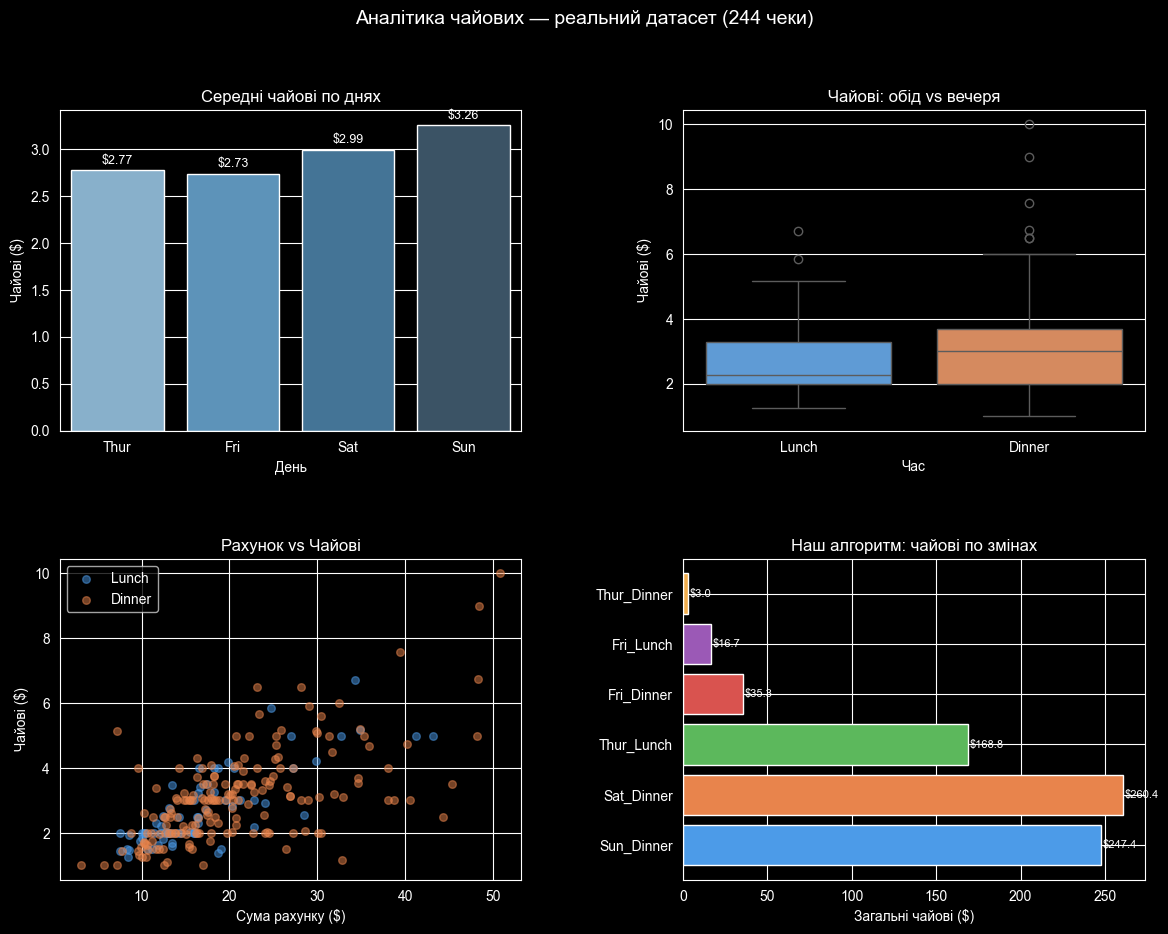

Графік збережено: tips_analysis.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

fig = plt.figure(figsize=(14, 10))
fig.suptitle("Аналітика чайових — реальний датасет (244 чеки)", fontsize=14, y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# --- Графік 1: Середні чайові по днях ---
ax1 = fig.add_subplot(gs[0, 0])
day_order = ["Thur", "Fri", "Sat", "Sun"]
sns.barplot(data=tips_df, x="day", y="tip", order=day_order, hue="day",
            palette="Blues_d", legend=False, ax=ax1, errorbar=None)
ax1.set_title("Середні чайові по днях")
ax1.set_xlabel("День")
ax1.set_ylabel("Чайові ($)")
for bar in ax1.patches:
    h = bar.get_height()
    if h > 0:
        ax1.text(bar.get_x() + bar.get_width() / 2, h + 0.04,
                 f"${h:.2f}", ha='center', va='bottom', fontsize=9)

# --- Графік 2: Lunch vs Dinner ---
ax2 = fig.add_subplot(gs[0, 1])
sns.boxplot(data=tips_df, x="time", y="tip", hue="time",
            palette=["#4C9BE8", "#E8844C"], legend=False, ax=ax2)
ax2.set_title("Чайові: обід vs вечеря")
ax2.set_xlabel("Час")
ax2.set_ylabel("Чайові ($)")

# --- Графік 3: Scatter — рахунок vs чайові ---
ax3 = fig.add_subplot(gs[1, 0])
colors = {"Lunch": "#4C9BE8", "Dinner": "#E8844C"}
for time_val, group in tips_df.groupby("time", observed=True):
    ax3.scatter(group["total_bill"], group["tip"],
                alpha=0.5, label=time_val, color=colors[time_val], s=30)
ax3.set_title("Рахунок vs Чайові")
ax3.set_xlabel("Сума рахунку ($)")
ax3.set_ylabel("Чайові ($)")
ax3.legend()

# --- Графік 4: Наш алгоритм → бар-чарт ---
ax4 = fig.add_subplot(gs[1, 1])
shifts   = list(tips_real.keys())
amounts  = [tips_real[s] for s in shifts]
bar_colors = ["#4C9BE8", "#E8844C", "#5CB85C", "#D9534F",
              "#9B59B6", "#F0AD4E", "#1ABC9C", "#E74C3C"][:len(shifts)]
bars = ax4.barh(shifts, amounts, color=bar_colors)
ax4.set_title("Наш алгоритм: чайові по змінах")
ax4.set_xlabel("Загальні чайові ($)")
for bar, val in zip(bars, amounts):
    ax4.text(val + 1, bar.get_y() + bar.get_height() / 2,
             f"${val:.1f}", va='center', fontsize=8)

plt.savefig("tips_analysis.png", dpi=120, bbox_inches='tight')
plt.show()
print("Графік збережено: tips_analysis.png")